### Add-K smoothing for n-gram language models

This notebook applies add-K smoothing with `K = 0.3` to unigram, bigram, trigram, and quadrigram models. The corpus and reproducible train/dev/test split follow Lab 4.

In [1]:
from collections import Counter
from math import exp, log
from pathlib import Path

import pandas as pd

K = 0.3
candidates = [
    Path.cwd() / "Lab 1" / "outputs" / "tokenized_sentences_with_source.txt",
    Path.cwd().parent / "Lab 1" / "outputs" / "tokenized_sentences_with_source.txt",
    Path(r"E:\STUDY\NLP\Lab 1\outputs\tokenized_sentences_with_source.txt"),
]
data_path = next((path for path in candidates if path.exists()), None)
if data_path is None:
    raise FileNotFoundError("Could not find tokenized_sentences_with_source.txt")

input_sentences = pd.read_json(data_path, lines=True)
sentences = [list(sentence) for sentence in input_sentences["word_tokens"] if sentence]
if len(sentences) < 3_000:
    raise ValueError("The corpus must contain at least 3,000 non-empty sentences.")

shuffled = pd.Series(range(len(sentences))).sample(frac=1, random_state=42).tolist()
test = [sentences[index] for index in shuffled[:1_000]]
dev = [sentences[index] for index in shuffled[1_000:2_000]]
train = [sentences[index] for index in shuffled[2_000:]]

print(f"Loaded {len(sentences):,} sentences from {data_path}")
print(f"Train: {len(train):,} | Dev: {len(dev):,} | Test: {len(test):,}")

Loaded 100,000 sentences from e:\STUDY\NLP\Lab 1\outputs\tokenized_sentences_with_source.txt
Train: 98,000 | Dev: 1,000 | Test: 1,000


In [2]:
class AddKNGramLanguageModel:
    """N-gram language model using add-K smoothing."""

    START = "<s>"
    END = "</s>"

    def __init__(self, n, k=K):
        if not isinstance(n, int) or n < 1:
            raise ValueError("n must be a positive integer")
        if not isinstance(k, (int, float)) or k <= 0:
            raise ValueError("k must be a positive number")
        self.n = n
        self.k = float(k)
        self.ngram_counts = Counter()
        self.context_counts = Counter()
        self.vocabulary = set()
        self.is_fitted = False

    def _padded(self, sentence):
        return [self.START] * (self.n - 1) + list(sentence) + [self.END]

    def fit(self, corpus):
        self.ngram_counts.clear()
        self.context_counts.clear()
        self.vocabulary.clear()
        for sentence in corpus:
            padded = self._padded(sentence)
            self.vocabulary.update(padded)
            for index in range(len(padded) - self.n + 1):
                ngram = tuple(padded[index:index + self.n])
                self.ngram_counts[ngram] += 1
                self.context_counts[ngram[:-1]] += 1
        self.is_fitted = True
        return self

    def probability(self, ngram):
        """Return (C(ngram)+K)/(C(context)+K*V)."""
        if not self.is_fitted:
            raise RuntimeError("Fit the model before requesting probabilities")
        ngram = tuple(ngram)
        if len(ngram) != self.n:
            raise ValueError(f"Expected an n-gram of length {self.n}")
        vocabulary_size = len(self.vocabulary)
        return (self.ngram_counts[ngram] + self.k) / (
            self.context_counts[ngram[:-1]] + self.k * vocabulary_size
        )

    def predict_next(self, context, top_k=5):
        context = tuple(context)[-(self.n - 1):] if self.n > 1 else ()
        candidates = [
            (token, self.probability(context + (token,)))
            for token in self.vocabulary if token != self.START
        ]
        return sorted(candidates, key=lambda item: (-item[1], item[0]))[:top_k]

    def sentence_log_probability(self, sentence):
        total = 0.0
        padded = self._padded(sentence)
        for index in range(len(padded) - self.n + 1):
            total += log(self.probability(padded[index:index + self.n]))
        return total

    def perplexity(self, corpus):
        log_probability = sum(self.sentence_log_probability(sentence) for sentence in corpus)
        token_count = sum(len(sentence) + 1 for sentence in corpus)
        return exp(-log_probability / token_count) if token_count else float("inf")

    def __repr__(self):
        return f"AddKNGramLanguageModel(n={self.n}, k={self.k})"

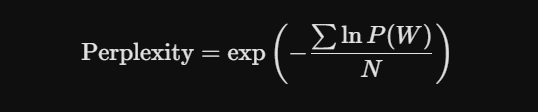

## Train models

In [3]:
models = {
    "Unigram": AddKNGramLanguageModel(1, K),
    "Bigram": AddKNGramLanguageModel(2, K),
    "Trigram": AddKNGramLanguageModel(3, K),
    "Quadrigram": AddKNGramLanguageModel(4, K),
}

for model in models.values():
    model.fit(train)
    print(f"{model}: V={len(model.vocabulary):,}, unique n-grams={len(model.ngram_counts):,}")

AddKNGramLanguageModel(n=1, k=0.3): V=139,533, unique n-grams=139,533
AddKNGramLanguageModel(n=2, k=0.3): V=139,534, unique n-grams=847,597
AddKNGramLanguageModel(n=3, k=0.3): V=139,534, unique n-grams=1,249,480
AddKNGramLanguageModel(n=4, k=0.3): V=139,534, unique n-grams=1,389,285


### Dev and test eval

For every model, the probability of an n-gram is:

$$P_{add-k}(w_i \mid w_{i-N+1}^{i-1}) = \frac{C(w_{i-N+1}^{i}) + k}{C(w_{i-N+1}^{i-1}) + kV}$$

With `K=0.3`, unseen n-grams receive a non-zero probability, so both held-out perplexities are finite.

In [4]:
evaluation = []
for name, model in models.items():
    evaluation.append({
        "model": name,
        "order": model.n,
        "k": model.k,
        "vocabulary_size": len(model.vocabulary),
        "dev_perplexity": model.perplexity(dev),
        "test_perplexity": model.perplexity(test),
    })

results = pd.DataFrame(evaluation)
display(results)
assert len(results) == 4
assert results[["dev_perplexity", "test_perplexity"]].map(pd.notna).all().all()

example_context = train[0][:3]
print(f"Example context: {example_context}")
for name, model in models.items():
    print(f"{name:10} -> {model.predict_next(example_context, top_k=3)}")

,model,order,k,vocabulary_size,dev_perplexity,test_perplexity
0,Unigram,1,0.3,139533,5492.051362,5594.706368
1,Bigram,2,0.3,139534,14036.223932,13847.920373
2,Trigram,3,0.3,139534,57248.164223,57221.108703
3,Quadrigram,4,0.3,139534,87848.727349,88578.688180


Example context: ['અને', 'હું', 'માનું']
Unigram    -> [('</s>', 0.06107631468390393), ('છે', 0.0385597900078084), ('અને', 0.017415608527947532)]
Bigram     -> [('છું', 0.00036535393961391885), ('</s>', 3.104314519595389e-05), ("છું'", 3.104314519595389e-05)]
Trigram    -> [('છું', 0.00019824114721913054), ("'", 7.165342670570982e-06), ("''", 7.165342670570982e-06)]
Quadrigram -> [('છું', 3.105501036759577e-05), ("'", 7.166540854060562e-06), ("''", 7.166540854060562e-06)]
